<a href="https://colab.research.google.com/github/nachenz/Pruebas-de-conocimiento/blob/main/Sistema_de_recomendacion_anime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Cargo desde Google Drive los archivos .CVS
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
#Asigno rutas a cada uno de los archivos
file_path_1 = '/content/drive/MyDrive/anime.csv'
file_path_2 = '/content/drive/MyDrive/rating.csv'


In [3]:
#Importo Pandas y le asigno una variable a cada archivo.

import pandas as pd

Anime = pd.read_csv(file_path_1)
Rating = pd.read_csv(file_path_2)


In [4]:
#Observo el DF Anime
Anime.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [5]:
#Sigo adentrandome en el DF
filas, columna = Anime.shape
print(f"El DataFrame tiene {filas} filas y {columna} columnas.")


El DataFrame tiene 12294 filas y 7 columnas.


In [6]:
#Elimino columnas que creo que no serán utiles en mi analisis
Anime_df = Anime.drop(['name', "members"], axis= 1)

In [7]:
#observo el DF resultante
Anime_df.head()

,anime_id,genre,type,episodes,rating
0,32281,"Drama, Romance, School, Supernatural",Movie,1,9.37
1,5114,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26
2,28977,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25
3,9253,"Sci-Fi, Thriller",TV,24,9.17
4,9969,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16


In [8]:
#Cuento cuantas veces aparece cada tipo de plataforma en la que se transmiten los anime
Plataforma = Anime_df['type'].value_counts()
print(Plataforma)

type
TV         3787
OVA        3311
Movie      2348
Special    1676
ONA         659
Music       488
Name: count, dtype: int64


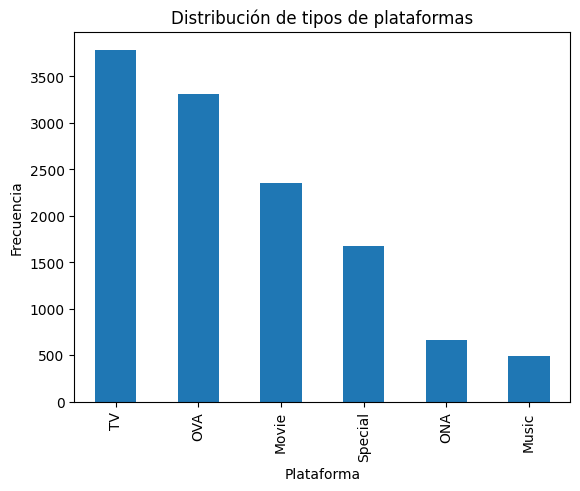

In [9]:
import matplotlib.pyplot as plt


Plataforma.plot(kind='bar')

plt.title('Distribución de tipos de plataformas')
plt.xlabel('Plataforma')
plt.ylabel('Frecuencia')

# Mostrar el gráfico
plt.show()


In [10]:
# Elimino los valores de "music" porque la idea es que se comparen solamente productos audivisuales y exclusivamente sonoros
Anime_df = Anime_df[~Anime_df['type'].isin(['Music'])]

Anime_df.head()


,anime_id,genre,type,episodes,rating
0,32281,"Drama, Romance, School, Supernatural",Movie,1,9.37
1,5114,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26
2,28977,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25
3,9253,"Sci-Fi, Thriller",TV,24,9.17
4,9969,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16


In [11]:
#Pido descripción de la columna anime_id
Anime_df.anime_id.describe()

,anime_id
count,11806.000000
mean,13711.532272
std,11371.644489
min,1.000000
25%,3324.250000
50%,9950.500000
75%,23970.500000
max,34527.000000


In [12]:
#Empiezo a trabajar con el 2do DF: Ratings
Rating.head(10)

,user_id,anime_id,rating
0,1,20,-1
1,1,24,-1
2,1,79,-1
3,1,226,-1
4,1,241,-1
5,1,355,-1
6,1,356,-1
7,1,442,-1
8,1,487,-1
9,1,846,-1


In [13]:
#Pido una descripcioón de este DF
Rating.describe()

,user_id,anime_id,rating
count,7.813737e+06,7.813737e+06,7.813737e+06
mean,3.672796e+04,8.909072e+03,6.144030e+00
std,2.099795e+04,8.883950e+03,3.727800e+00
min,1.000000e+00,1.000000e+00,-1.000000e+00
25%,1.897400e+04,1.240000e+03,6.000000e+00
50%,3.679100e+04,6.213000e+03,7.000000e+00
75%,5.475700e+04,1.409300e+04,9.000000e+00
max,7.351600e+04,3.451900e+04,1.000000e+01


In [14]:
# Filtro para el train los rating entre 2 y menores a 10
train = Rating[(Rating['rating'] >= 2) & (Rating['rating'] < 10)]

train.head()


,user_id,anime_id,rating
156,3,20,8
157,3,154,6
158,3,170,9
160,3,225,9
161,3,341,6


In [15]:
#Miro el tamaño del train
train.shape

(5364877, 3)

In [16]:
#Observo cuantos Usuarios aparecen
train.user_id.nunique()

66255

In [17]:
#Testeo con datos cuyo valor de rating haya sido 10
test = Rating[(Rating['rating'] == 10)]
test.head()

,user_id,anime_id,rating
47,1,8074,10
81,1,11617,10
83,1,11757,10
101,1,15451,10
153,2,11771,10


In [18]:
#Miro el tamaño del test
test.shape

(955715, 3)

In [19]:
#Veo cuales son los valores unicos de usuarios que dieron esa puntuación
test.user_id.nunique()

62029

In [20]:
#Veo cuantos usuarios del test no estan en el train
test[~test.user_id.isin(train.user_id.unique())].user_id.nunique()

3318

In [21]:
#Genero la tabla matrix
matrix_columns = ["user_id", "anime_id", "rating"]

In [22]:

interactions = train[matrix_columns]
interactions.head()

,user_id,anime_id,rating
156,3,20,8
157,3,154,6
158,3,170,9
160,3,225,9
161,3,341,6


In [23]:
from scipy.sparse import csr_matrix

In [24]:
interactions_matrix_csr = csr_matrix(interactions.values)

In [25]:
interactions_matrix_csr

<5364877x3 sparse matrix of type '<class 'numpy.int64'>'
	with 16094631 stored elements in Compressed Sparse Row format>

In [26]:
#Al haber tantos datos, y luego de muchas saturaciones de RAM en google colab, me doy cuenta que es mejor comprimir los datos y luego generar un diccionario con los IDs de los usuarios, ratings y nombres de los anime calificados
user_ids = list(interactions.index)
user_dict = {}
counter = 0
for i in user_ids:
    user_dict[i] = counter
    counter += 1

In [27]:
#Veo el diccionario
user_dict

{156: 0,
 157: 1,
 158: 2,
 160: 3,
 161: 4,
 162: 5,
 163: 6,
 164: 7,
 166: 8,
 167: 9,
 168: 10,
 169: 11,
 170: 12,
 171: 13,
 172: 14,
 174: 15,
 175: 16,
 176: 17,
 177: 18,
 178: 19,
 179: 20,
 180: 21,
 181: 22,
 182: 23,
 184: 24,
 185: 25,
 186: 26,
 187: 27,
 188: 28,
 189: 29,
 190: 30,
 191: 31,
 192: 32,
 193: 33,
 194: 34,
 196: 35,
 197: 36,
 198: 37,
 199: 38,
 200: 39,
 201: 40,
 202: 41,
 204: 42,
 205: 43,
 206: 44,
 207: 45,
 210: 46,
 211: 47,
 213: 48,
 214: 49,
 215: 50,
 217: 51,
 218: 52,
 219: 53,
 220: 54,
 222: 55,
 223: 56,
 224: 57,
 225: 58,
 226: 59,
 227: 60,
 228: 61,
 229: 62,
 230: 63,
 231: 64,
 232: 65,
 233: 66,
 234: 67,
 236: 68,
 237: 69,
 238: 70,
 239: 71,
 241: 72,
 242: 73,
 243: 74,
 244: 75,
 245: 76,
 249: 77,
 302: 78,
 303: 79,
 304: 80,
 305: 81,
 306: 82,
 307: 83,
 310: 84,
 311: 85,
 312: 86,
 314: 87,
 315: 88,
 316: 89,
 317: 90,
 318: 91,
 319: 92,
 320: 93,
 321: 94,
 322: 95,
 323: 96,
 324: 97,
 325: 98,
 326: 99,
 327: 100,

In [28]:
pip install lightfm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.4/316.4 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lightfm: filename=lightfm-1.17-cp311-cp311-linux_x86_64.whl size=831161 sha256=160638c5eedcd1ec06cf2bd51cc9cc510f95194117404fdc034376a462caa4f9
  Stored in directory: /root/.cache/pip/wheels/b9/0d/8a/0729d2e6e3ca2a898ba55201f905da7db3f838a33df5b3fcdd
Successfully built lightfm


In [29]:
#Importo libreria LightFM de recomendaciones y creo un modelo
from lightfm import LightFM

model = LightFM(no_components=3, random_state=100, learning_rate=0.03)

In [32]:
model = model.fit(interactions_matrix_csr, epochs=10)

In [33]:
#Selecciono un usuario especifico (24) para hacerle recomendaciones
import numpy as np
user_x = user_ids[24]
n_users, n_items = interactions_matrix_csr.shape
item_ids = np.arange(n_items)
preds = model.predict(user_ids=user_x, item_ids = item_ids)

In [34]:
scores = pd.Series(preds)
scores.index = interactions.columns
recomms_24 = list(pd.Series(scores.sort_values(ascending=False).index))[:10] #obtenemos las primeras 10

In [35]:
#Miro la veces que el usuario sale como valor unico
train[(train.user_id==24)].anime_id.unique()

array([   30,    66,    72,   226,   227,   270,   357,   376,   659,
         777,  1593,  1696,  1887,  2131,  2759,  3342,  3784,  3785,
        4654,  5030,  5680,  6203,  6547,  6746,  6974,  7059,  7748,
        8074,  8795,  8857,  9014,  9041,  9515, 10067, 10490, 10495,
       10794, 11079, 11111, 11285, 11757, 14741, 15687, 15879, 16498,
       16592, 16742, 16934, 20159])

In [36]:
#Obtengo los anime únicos que el usuario 24 ya ha interactuado y que están en la lista de recomendaciones recomms_24.
train[(train.user_id==24) & (train.anime_id.isin(recomms_24))].anime_id.unique()

array([], dtype=int64)

In [37]:
#Veo los animes únicos que el usuario 24 ya vio visto de los del train.

user_24_watched = train[train.user_id == 24].anime_id.unique()

In [38]:
#Genero la variable recomms_24, eliminando los anime ya vistos por el usario
recomms_24 = [rec for rec in recomms_24 if rec not in user_24_watched]

In [39]:
recomms_24

['user_id', 'anime_id', 'rating']

In [40]:
train.head()

,user_id,anime_id,rating
156,3,20,8
157,3,154,6
158,3,170,9
160,3,225,9
161,3,341,6


In [41]:
#Busco cuántos usuarios únicos vieron cada anime.

train.groupby("anime_id", as_index=False).agg({"user_id":"nunique"})

,anime_id,user_id
0,1,8284
1,5,4661
2,6,7444
3,7,2004
4,8,287
...,...,...
9850,34324,11
9851,34325,14
9852,34349,3
9853,34367,4


In [42]:
#Se genera un DF a raiz de la popularidad de cada Anime con respecto a los ratings
popularity_df = train.groupby("anime_id", as_index=False).agg({"user_id":"nunique"}).sort_values(by="user_id", ascending=False)

popularity_df.columns=["anime_id", "rating"]
popularity_df.head()

,anime_id,rating
1388,1535,21304
6299,11757,19484
201,226,18568
10,20,18493
7031,16498,17086


In [43]:
#Veo los 10 animes mas populares
popular_content = popularity_df.anime_id.values[:10]

In [44]:
popularity_df.head(10).anime_id.values

array([ 1535, 11757,   226,    20, 16498,  8074,  6547,   121,  4224,
        9919])

In [45]:
#Veo el total de intereacciones de cada usario con el anime y sus rating
interactions.head()

,user_id,anime_id,rating
156,3,20,8
157,3,154,6
158,3,170,9
160,3,225,9
161,3,341,6


In [46]:
interactions.shape

(5364877, 3)

In [47]:
interactions.index

Index([    156,     157,     158,     160,     161,     162,     163,     164,
           166,     167,
       ...
       7813726, 7813727, 7813728, 7813729, 7813730, 7813731, 7813732, 7813733,
       7813735, 7813736],
      dtype='int64', length=5364877)

In [ ]:
from tqdm import tqdm

#definimos dict donde vamos a ir almacenando las recomendaciones
recomms_dict = {
    'user_id': [],
    'recomms': []
}

#obtenemos cantidad de usuarios y cantidad de items
n_users, n_items = interactions.shape
item_ids = np.arange(n_items)

#por cada usuario del dataset de test, generamos recomendaciones
for user in tqdm(test.user_id.unique()):
    #COMPLETAR: Validar si el usuario se encuentra en la matriz de interacciones (interactions_matrix.index)
    if user in list(interactions.index):
      # Si el usuario esta en train, no es cold start. Usamos el modelo para recomendar
      user_x = user_dict[user] #buscamos el indice del usuario en la matriz (transformamos id a indice)

      #COMPLETAR: Generar las predicciones para el usuario x
      preds = model.predict(user_ids=user_x, item_ids = item_ids)

      #COMPLETAR: Basándose en el ejemplo anterior, ordenar las predicciones de menor a mayor y quedarse con 50.
      scores = pd.Series(preds)
      scores.index = interactions.columns
      scores = list(pd.Series(scores.sort_values(ascending=False).index))[:50]

      #COMPLETAR: Obtener listado de contenidos vistos anteriormente por el usuario (en el set de train)
      watched_contents = train[train.user_id == user].anime_id.unique()

      #COMPLETAR: Filtrar contenidos ya vistos y quedarse con los primeros 10
      recomms = [x for x in scores if x not in watched_contents][:10]

      # Guardamos las recomendaciones en el diccionario
      recomms_dict['user_id'].append(user)
      recomms_dict['recomms'].append(scores)

    # En este else trataremos a los usuarios que no están en la matriz (cold start)
    else:
      recomms_dict['user_id'].append(user)
      # Les recomendamos contenido popular
      recomms_dict['recomms'].append(popular_content)




  5%|▌         | 3221/62029 [44:00<11:47:25,  1.39it/s]

In [ ]:
recomms_df = pd.DataFrame(recomms_dict)
recomms_df